# 18 — Discrete time / `c2d` (`math`, SciPy, PyTorch, python-control)

Sample the notebook-`14` plant three ways:

| Method | python-control / SciPy name | Meaning |
| --- | --- | --- |
| ZOH | `zoh` | hold \(u(t)\) constant over each \(T_s\) |
| Tustin | `tustin` / `bilinear` | \(s = \frac{2}{T}\frac{z-1}{z+1}\) |
| forward Euler | `euler` / `forward_diff` | \(s = (z-1)/T\) |

Then run the discrete state update on the GPU for a **batch of sample rates**.

In [1]:
from __future__ import annotations

import math
import time

import control as ct
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import signal

%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"python-control {ct.__version__}   torch {torch.__version__}   device {device}")
if device.type == "cuda":
    print(f"CUDA {torch.version.cuda}  |  {torch.cuda.get_device_name(0)}")


python-control 0.10.2   torch 2.14.0+cu132   device cuda
CUDA 13.2  |  NVIDIA GeForce RTX 3060


In [2]:
def bode_mag_phase(sys, omega):
    frd = ct.frequency_response(sys, omega=omega)
    if hasattr(frd, "magnitude"):
        w = np.asarray(frd.frequency).reshape(-1)
        m = np.asarray(frd.magnitude).reshape(-1)
        p = np.asarray(frd.phase).reshape(-1)
    else:
        mag, phase, om = frd
        w = np.asarray(om).reshape(-1)
        m = np.asarray(mag).reshape(-1)
        p = np.asarray(phase).reshape(-1)
    return w, m, p


def plot_bode(sys, title, marks=()):
    w, m, p = bode_mag_phase(sys, np.logspace(0, 5, 500))
    fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
    axes[0].semilogx(w / (2 * np.pi), 20 * np.log10(np.maximum(m, 1e-16)))
    axes[1].semilogx(w / (2 * np.pi), np.degrees(np.unwrap(p)))
    for f, lab in marks:
        axes[0].axvline(f, color="k", ls="--", lw=1, label=lab)
        axes[1].axvline(f, color="k", ls="--", lw=1)
    axes[0].set_ylabel("mag (dB)")
    axes[1].set_ylabel("phase (deg)")
    axes[1].set_xlabel("frequency (Hz)")
    for ax in axes:
        ax.grid(True, which="both", alpha=0.3)
    if marks:
        axes[0].legend()
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    return w, m, p


def max_abs(a, b) -> float:
    return float(np.max(np.abs(np.asarray(a, dtype=np.float64) - np.asarray(b, dtype=np.float64))))


In [3]:
FN_HZ = 8.0
ZETA = 0.20
DURATION_S = 0.80
FS_REF = 8_192
WN = 2.0 * math.pi * FN_HZ
G = ct.tf([WN**2], [1.0, 2.0 * ZETA * WN, WN**2])
print(G)
print(f"device = {device}")

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          2527
  --------------------
  s^2 + 20.11 s + 2527
device = cuda


## python-control — `c2d` comparison at 64 Hz vs 8 kHz

zoh      vs continuous  5.487e-12
tustin   vs continuous  2.316e-03
euler    vs continuous  5.675e-03


/projects/ControlsMachineLearning/.venv/lib/python3.12/site-packages/scipy/signal/_lti_conversion.py:77: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  num, den = normalize(num, den)   # Strips zeros, checks arrays


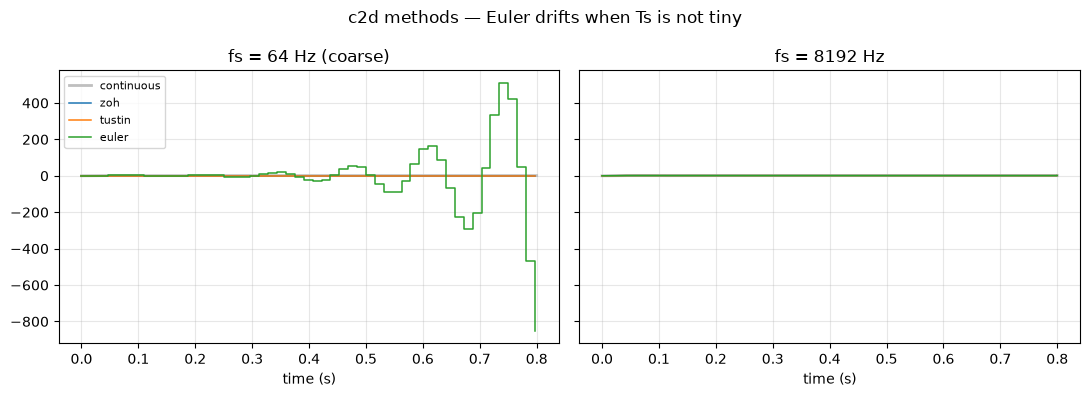

In [4]:
def step_c2d(method, fs, t_end=DURATION_S):
    dt = 1.0 / fs
    td = np.arange(0.0, t_end, dt)
    ud = np.ones_like(td)
    sysd = ct.c2d(G, dt, method=method)
    _t, y = ct.forced_response(sysd, T=td, U=ud)
    return td, y, sysd


t_c, y_c = ct.forced_response(G, T=np.arange(0.0, DURATION_S, 1.0 / FS_REF), U=1.0)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, fs, title in ((axes[0], 64, "fs = 64 Hz (coarse)"), (axes[1], FS_REF, "fs = 8192 Hz")):
    ax.plot(t_c, y_c, color="0.75", lw=2.0, label="continuous")
    for method in ("zoh", "tustin", "euler"):
        td, yd, sysd = step_c2d(method, fs)
        ax.step(td, yd, where="post", lw=1.1, label=method)
        if fs == FS_REF:
            print(f"{method:8} vs continuous  {max_abs(y_c[: len(yd)], yd[: len(y_c)]):.3e}")
    ax.set_title(title)
    ax.set_xlabel("time (s)")
    ax.grid(True, alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle("c2d methods — Euler drifts when Ts is not tiny")
fig.tight_layout()
plt.show()

## `math` — discrete ZOH matrices by hand (2nd-order hold formula via `expm` idea)

We take \(A_d, B_d\) from SciPy and apply them with lists, so the recurrence is readable.

In [5]:
dt = 1.0 / 256.0
A, B, C, D = ct.tf2ss(G).A, ct.tf2ss(G).B, ct.tf2ss(G).C, ct.tf2ss(G).D
A = np.asarray(A); B = np.asarray(B); C = np.asarray(C); D = np.asarray(D)
Ad, Bd, Cd, Dd, _ = signal.cont2discrete((A, B, C, D), dt=dt, method="zoh")


def math_discrete(u_list, Ad, Bd, Cd, Dd):
    n = Ad.shape[0]
    x = [0.0] * n
    out = []
    for un in u_list:
        y = Dd[0, 0] * un + sum(Cd[0, i] * x[i] for i in range(n))
        xn = [0.0] * n
        for i in range(n):
            s = Bd[i, 0] * un
            for j in range(n):
                s += Ad[i, j] * x[j]
            xn[i] = s
        x = xn
        out.append(y)
    return out


td = np.arange(0.0, DURATION_S, dt)
ud = np.ones_like(td)
_, y_zoh, _ = step_c2d("zoh", 256)
y_math = math_discrete(ud.tolist(), Ad, Bd, Cd, Dd)
print("math ZOH vs control c2d(zoh)", max_abs(y_zoh[: len(y_math)], y_math))

math ZOH vs control c2d(zoh) 1.7763568394002505e-15


## SciPy — `cont2discrete` for all three methods

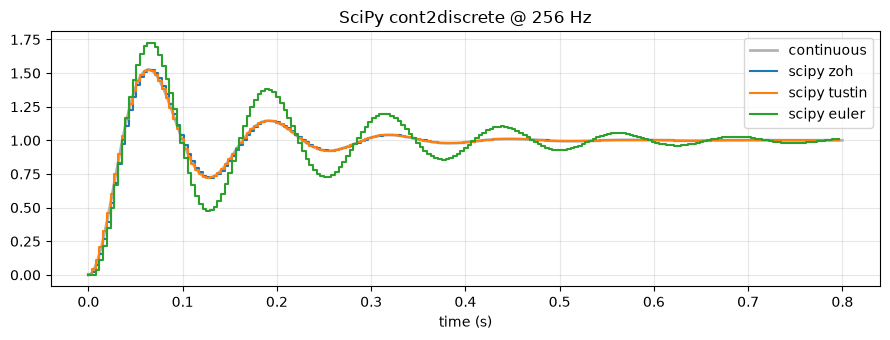

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t_c, y_c, color="0.7", lw=2, label="continuous")
for method, label in (("zoh", "zoh"), ("bilinear", "tustin"), ("euler", "euler")):
    Adi, Bdi, Cdi, Ddi, _ = signal.cont2discrete((A, B, C, D), dt=dt, method=method)
    x = np.zeros((2, 1))
    ys = []
    for un in ud:
        ys.append(float(np.asarray(Cdi @ x + Ddi * un).reshape(-1)[0]))
        x = Adi @ x + Bdi * un
    ax.step(td, ys, where="post", label=f"scipy {label}")
ax.set_xlabel("time (s)")
ax.set_title("SciPy cont2discrete @ 256 Hz")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## PyTorch — batched discrete SS over many \(T_s\)

Each batch item is a different sample period. We precompute `(Ad, Bd)` on the host (matrix exponential is not the point here) and run the recurrence on `cuda`.

ZOH batch B=11 Tmax=6553 on cuda:0 in 1254.7 ms


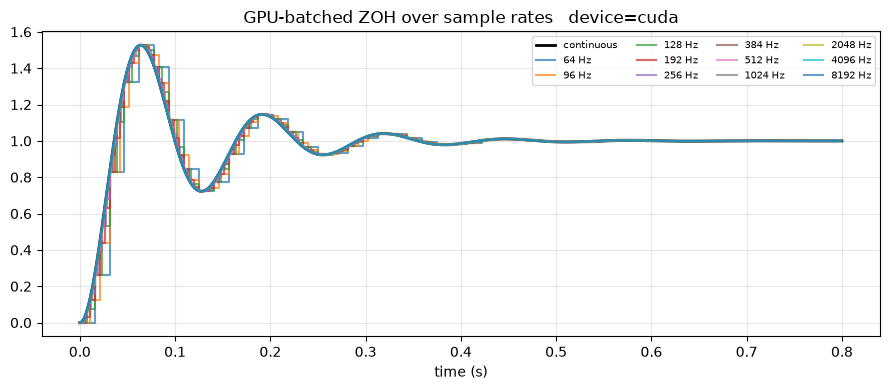

8 kHz ZOH vs continuous 5.994495225758456e-06


In [7]:
fs_list = [64, 96, 128, 192, 256, 384, 512, 1024, 2048, 4096, 8192]
methods = ("zoh", "bilinear", "euler")
T_max = int(DURATION_S * max(fs_list))


def pack_discrete(method):
    Ads, Bds, Cds, Dds, nsteps = [], [], [], [], []
    for fs in fs_list:
        dti = 1.0 / fs
        Adi, Bdi, Cdi, Ddi, _ = signal.cont2discrete((A, B, C, D), dt=dti, method=method)
        Ads.append(Adi)
        Bds.append(Bdi.reshape(2))
        Cds.append(Cdi.reshape(2))
        Dds.append(float(np.asarray(Ddi).reshape(-1)[0]))
        nsteps.append(int(DURATION_S * fs))
    return (
        torch.as_tensor(np.stack(Ads), device=device, dtype=torch.float32),
        torch.as_tensor(np.stack(Bds), device=device, dtype=torch.float32),
        torch.as_tensor(np.stack(Cds), device=device, dtype=torch.float32),
        torch.as_tensor(Dds, device=device, dtype=torch.float32),
        nsteps,
    )


def torch_discrete_batch(Ad_b, Bd_b, Cd_b, Dd_b, nsteps, t_end=DURATION_S):
    Bsz = Ad_b.shape[0]
    nT = max(nsteps)
    x = torch.zeros(Bsz, 2, device=Ad_b.device, dtype=Ad_b.dtype)
    y = torch.zeros(Bsz, nT, device=Ad_b.device, dtype=Ad_b.dtype)
    nstep_t = torch.tensor(nsteps, device=Ad_b.device)
    for k in range(nT):
        active = k < nstep_t
        u = torch.ones(Bsz, device=Ad_b.device, dtype=Ad_b.dtype)
        yk = (x * Cd_b).sum(dim=1) + Dd_b * u
        x_new = torch.bmm(Ad_b, x.unsqueeze(-1)).squeeze(-1) + Bd_b * u.unsqueeze(-1)
        y[:, k] = torch.where(active, yk, y[:, k])
        x = torch.where(active.unsqueeze(-1), x_new, x)
    return y


Ad_b, Bd_b, Cd_b, Dd_b, nsteps = pack_discrete("zoh")
if device.type == "cuda":
    torch.cuda.synchronize()
t0 = time.perf_counter()
y_b = torch_discrete_batch(Ad_b, Bd_b, Cd_b, Dd_b, nsteps)
if device.type == "cuda":
    torch.cuda.synchronize()
print(f"ZOH batch B={len(fs_list)} Tmax={y_b.shape[1]} on {y_b.device} in {(time.perf_counter()-t0)*1e3:.1f} ms")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_c, y_c, color="k", lw=2.0, label="continuous")
for i, fs in enumerate(fs_list):
    ns = nsteps[i]
    ti = np.arange(ns) / fs
    ax.step(ti, y_b[i, :ns].detach().cpu().numpy(), where="post", alpha=0.7, label=f"{fs} Hz")
ax.set_xlabel("time (s)")
ax.set_title(f"GPU-batched ZOH over sample rates   device={device}")
ax.grid(True, alpha=0.3)
ax.legend(ncol=4, fontsize=7)
fig.tight_layout()
plt.show()
n_cmp = min(len(y_c), int(y_b.shape[1]))
print("8 kHz ZOH vs continuous", max_abs(y_c[:n_cmp], y_b[-1, :n_cmp].detach().cpu().numpy()))

## Takeaways

- ZOH is the right model of a DAC / zero-order hold. Tustin matches frequency response better near Nyquist.
- Forward Euler is what notebooks `10`–`17` used — fine at 8 kHz vs 8 Hz, sloppy at 64 Hz.
- Discrete update \(x^+ = A_d x + B_d u\) is a batched GEMM; that is the GPU form.
- Next (`19`): compare these plants in the **frequency domain** with Bode vs `torch.fft`.